# Extreme magnetopause compression during the May 2024 Gannon storm

On 10 May 2024, an interplanetary coronal mass ejection drove an extreme geomagnetic storm. The dayside magnetopause, normally about 10–12 Earth radii ($R_E$) from Earth near the subsolar point, was compressed inside geosynchronous orbit.

In this notebook we use **PySPEDAS 2.2.0** to connect three views of the event:

1. the boundary crossing and fast plasma flow measured by THEMIS-A;
2. the upstream magnetic-field and solar-wind transition measured by THEMIS-B; and
3. the sharply structured response measured by ground magnetometers.

The scientific motivation and reported event times come from [Fu et al. (2025), *Compression of Earth's Magnetopause Down to 5 $R_E$ During the Superstorm on 10 May 2024*](https://doi.org/10.1029/2024GL114040). We will inspect the observations before using those reported times as guides.

## 1. Imports and event interval

PySPEDAS 2.2.0 includes the tplot interface in the `pyspedas` package, so a separate `pytplot` import is not needed. Data-loading cells use `time_clip=True` to keep the in-memory variables restricted to our 40-minute interval.

In [1]:
# This line installs PySPEDAS so the notebook can be used in Google Colab.  You can comment
# it out or skip this cell if you already have a suitable PySPEDAS installation.

!pip install "pyspedas>=2.2.0"

In [2]:
from importlib.metadata import version
from pprint import pprint

import numpy as np
import pyspedas
from pyspedas import (
    get_data, options, store_data, time_double, timebar, tplot, tplot_names
)

print("PySPEDAS version:", version("pyspedas"))

PySPEDAS version: 2.2.0


In [3]:
trange = ["2024-05-10/16:50", "2024-05-10/17:30"]
trange

['2024-05-10/16:50', '2024-05-10/17:30']

## 2. Load THEMIS-A magnetic field, ion moments, and position

We use the spin-resolution FGM magnetic field and the reduced ESA ion moments. On this interval the reduced ion product has much better time resolution than the full-distribution moments, while keeping the download modest. The state data let us check where THEMIS-A was when the transition occurred.

In [4]:
fgm_a_vars = pyspedas.projects.themis.fgm(
    probe="a", trange=trange,
    varnames=["tha_fgs_gsm", "tha_fgs_btotal"],
    time_clip=True,
)
esa_a_vars = pyspedas.projects.themis.esa(
    probe="a", trange=trange,
    varnames=["tha_peir_density", "tha_peir_velocity_gsm"],
    time_clip=True,
)
state_a_vars = pyspedas.projects.themis.state(
    probe="a", trange=trange,
    varnames=["tha_pos_gsm"],
    time_clip=True,
)

print("FGM returned:", fgm_a_vars)
print("ESA returned:", esa_a_vars)
print("State returned:", state_a_vars)

25-Sep-26 10:15:59: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fgm/2024/
25-Sep-26 10:16:00: File is current: themis_data/tha/l2/fgm/2024/tha_l2_fgm_20240510_v01.cdf
25-Sep-26 10:16:00: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/esa/2024/
25-Sep-26 10:16:02: File is current: themis_data/tha/l2/esa/2024/tha_l2_esa_20240510_v01.cdf
25-Sep-26 10:16:02: File is current: themis_data/tha/l1/state/2024/tha_l1_state_20240510.cdf


FGM returned: ['tha_fgs_gsm', 'tha_fgs_btotal']
ESA returned: ['tha_peir_density', 'tha_peir_velocity_gsm']
State returned: ['tha_pos_gsm']


### Inspect variable names and metadata

A PySPEDAS loader returns the names of the tplot variables it created. It is good practice to inspect that return value and the metadata before plotting; mission naming conventions encode the probe, instrument, data cadence, and coordinates.

In [5]:
# Use explicit names after inspecting the loader returns above.
a_b_gsm = "tha_fgs_gsm"
a_density = "tha_peir_density"
a_velocity = "tha_peir_velocity_gsm"
a_position = "tha_pos_gsm"

expected_a = [a_b_gsm, a_density, a_velocity, a_position]
returned_a = fgm_a_vars + esa_a_vars + state_a_vars
for name in expected_a:
    if name not in returned_a or get_data(name) is None:
        raise RuntimeError(f"Expected variable {name!r} was not loaded")

print("Current tplot variables:")
print(tplot_names())
print("\nSelected metadata for", a_b_gsm)
b_metadata = get_data(a_b_gsm, metadata=True)
pprint({
    "labels": b_metadata["CDF"].get("LABELS"),
    "data_attributes": b_metadata.get("data_att"),
})

Current tplot variables:
0 : tha_fgs_gsm
1 : tha_fgs_btotal
2 : tha_peir_density
3 : tha_peir_velocity_gsm
4 : tha_pos_gsm
['tha_fgs_gsm', 'tha_fgs_btotal', 'tha_peir_density', 'tha_peir_velocity_gsm', 'tha_pos_gsm']

Selected metadata for tha_fgs_gsm
{'data_attributes': {'coord_sys': 'GSM',
                     'depend_1_units': 'nT GSM',
                     'depend_2_units': None,
                     'depend_3_units': None,
                     'units': 'nT GSM'},
 'labels': ['Bx FGS-A', 'By FGS-A', 'Bz FGS-A']}


In [6]:
# Report the THEMIS-A position nearest 17:05 UT in Earth radii.
position = get_data(a_position)
crossing_guess = time_double("2024-05-10/17:05")
nearest = np.argmin(np.abs(position.times - crossing_guess))
earth_radius_km = 6371.0
print("THEMIS-A GSM position near 17:05 UT [R_E]:",
      np.round(position.y[nearest] / earth_radius_km, 2))

THEMIS-A GSM position near 17:05 UT [R_E]: [ 7.72  3.05 -1.92]


### First look: find the transitions yourself

The magnetic-field and velocity vectors below are in GSM coordinates. Before reading ahead, look for (1) the abrupt loss or reversal of the quiet northward $B_z$, and (2) the first large anti-sunward ion flow ($V_x < 0$). Do they happen at exactly the same time?

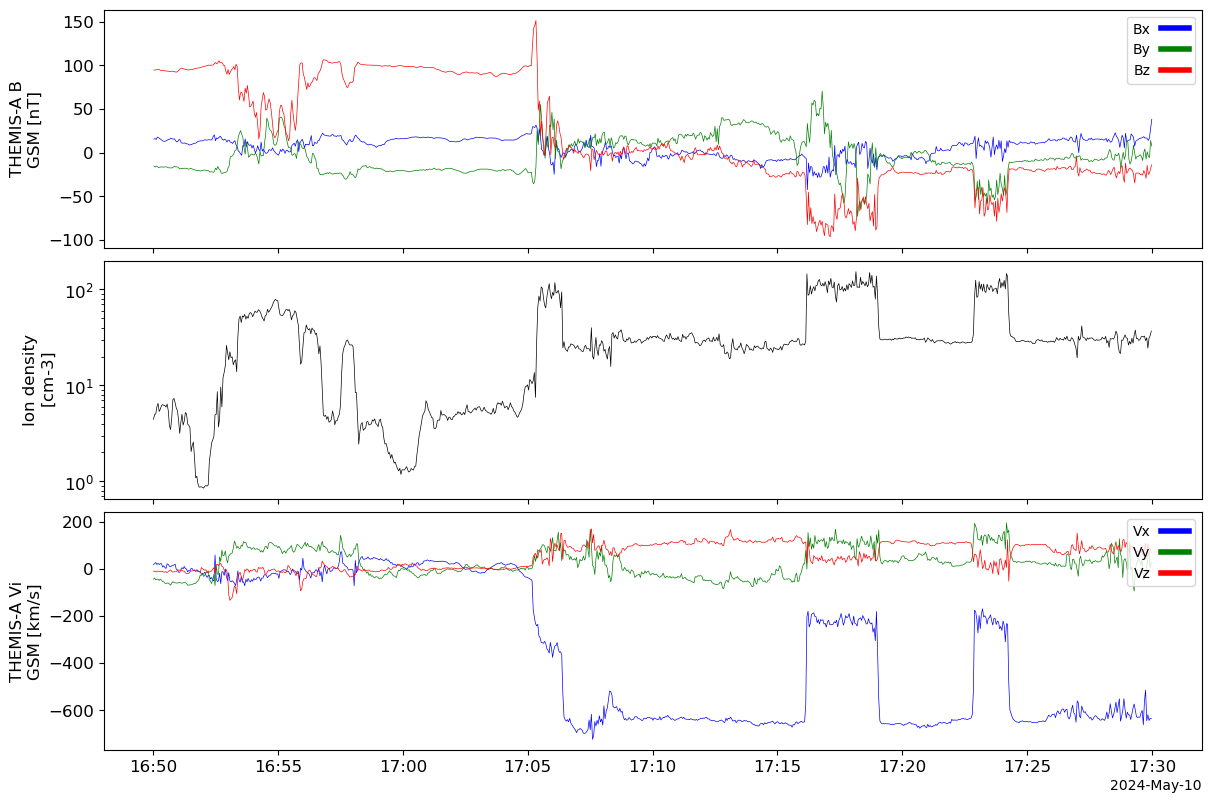

In [7]:
options(a_b_gsm, "ytitle", "THEMIS-A B")
options(a_b_gsm, "ysubtitle", "GSM [nT]")
options(a_b_gsm, "legend_names", ["Bx", "By", "Bz"])
options(a_density, "ytitle", "Ion density")
options(a_density, "ysubtitle", "[cm^-3]")
options(a_velocity, "ytitle", "THEMIS-A Vi")
options(a_velocity, "ysubtitle", "GSM [km/s]")
options(a_velocity, "legend_names", ["Vx", "Vy", "Vz"])

tplot([a_b_gsm, a_density, a_velocity], xsize=12, ysize=8)

Fu et al. identify the primary THEMIS-A magnetopause crossing at about **17:05 UT**, followed roughly one minute later by fast flow. They also report stronger-field, low-flow intervals near **17:16 UT** and **17:23 UT**, interpreted as additional bow-shock/magnetosheath encounters. Treat those times as guides and decide what signatures in the plot support each interpretation.

## 3. Upstream context from THEMIS-B

THEMIS-B was far upstream of Earth. FGM shows the sharp magnetic transition before the response at THEMIS-A. For the plasma, we use the Level-2 MOM product: `thb_peim_density` and `thb_peim_velocity_gsm` are onboard ESA ion moments with about 4.3 s cadence during this interval. This avoids the fill velocity in the reduced omnidirectional ESA product and the sparse cadence of the full-distribution moments.

We also calculate a simple proton-only dynamic pressure, $P_{dyn}=m_p n |V|^2$. This derived quantity neglects alpha particles and other composition effects, so compare it with the paper's reported value as an approximation. Focus on the sustained change in $V_x$; brief sign reversals remain in the delivered onboard-moment data.

25-Sep-26 10:16:03: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thb/l2/fgm/2024/
25-Sep-26 10:16:04: File is current: themis_data/thb/l2/fgm/2024/thb_l2_fgm_20240510_v01.cdf
25-Sep-26 10:16:04: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thb/l2/mom/2024/
25-Sep-26 10:16:05: File is current: themis_data/thb/l2/mom/2024/thb_l2_mom_20240510_v01.cdf


THEMIS-B FGM returned: ['thb_fgs_gsm', 'thb_fgs_btotal']
THEMIS-B MOM returned: ['thb_peim_density', 'thb_peim_velocity_gsm']
MOM samples: 558; median cadence: 4.30 s


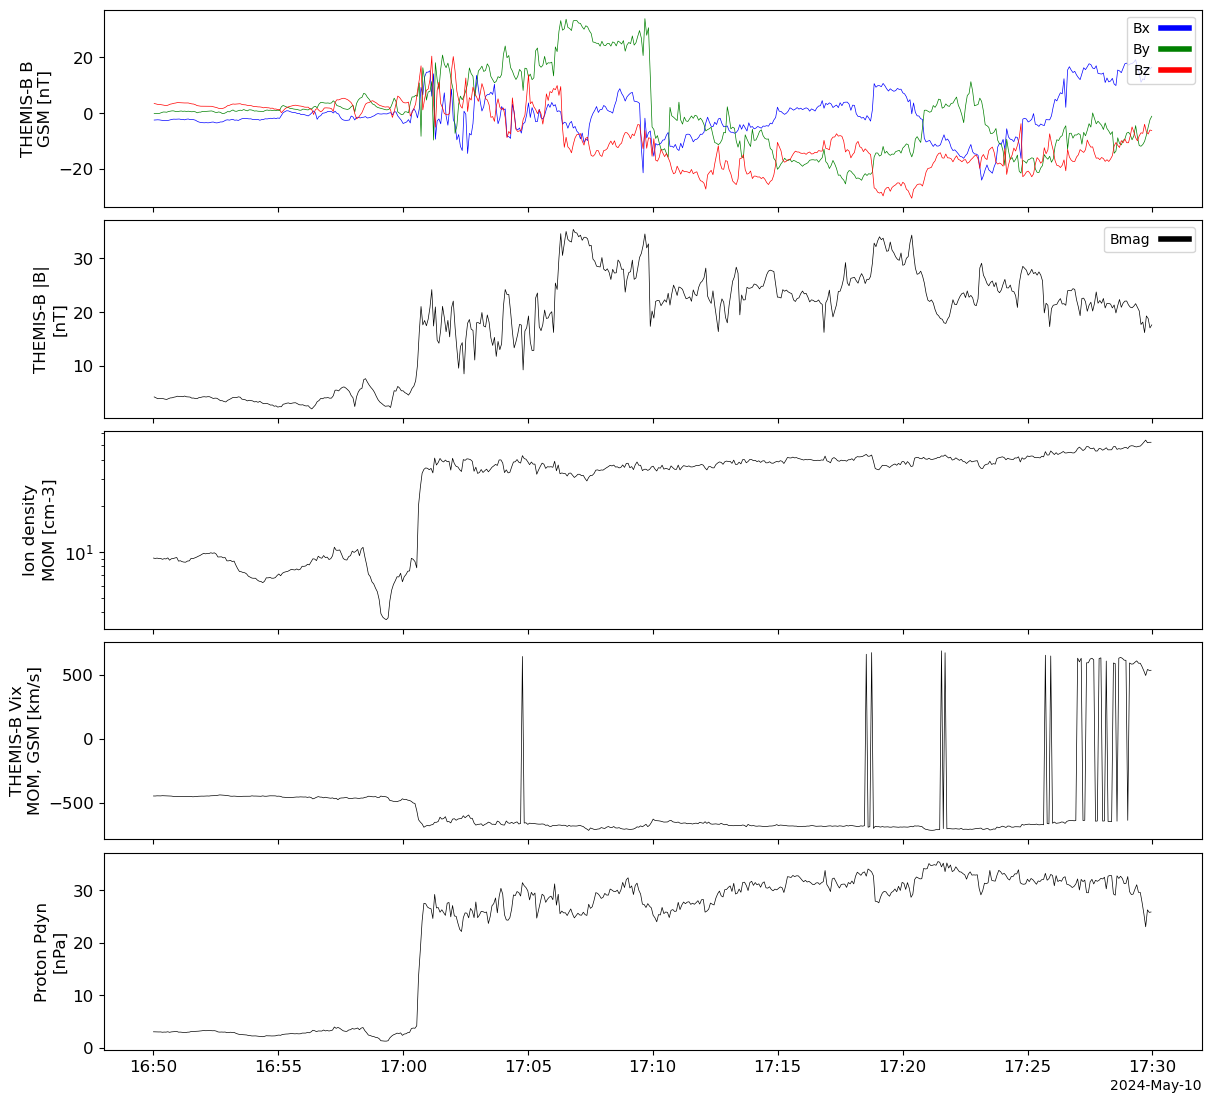

In [8]:
fgm_b_vars = pyspedas.projects.themis.fgm(
    probe="b", trange=trange,
    varnames=["thb_fgs_gsm", "thb_fgs_btotal"],
    time_clip=True,
)
mom_b_vars = pyspedas.projects.themis.mom(
    probe="b", trange=trange,
    varnames=["thb_peim_density", "thb_peim_velocity_gsm"],
    time_clip=True,
)
print("THEMIS-B FGM returned:", fgm_b_vars)
print("THEMIS-B MOM returned:", mom_b_vars)

b_b_gsm = "thb_fgs_gsm"
b_btotal = "thb_fgs_btotal"
b_density = "thb_peim_density"
b_velocity = "thb_peim_velocity_gsm"
expected_b = [b_b_gsm, b_btotal, b_density, b_velocity]
returned_b = fgm_b_vars + mom_b_vars
for name in expected_b:
    if name not in returned_b or get_data(name) is None:
        raise RuntimeError(f"Expected variable {name!r} was not loaded")

# The MOM density and velocity share the same timestamps here.
density_data = get_data(b_density)
velocity_data = get_data(b_velocity)
if not np.array_equal(density_data.times, velocity_data.times):
    raise RuntimeError("THEMIS-B MOM density and velocity times do not match")
mom_cadence = np.nanmedian(np.diff(density_data.times))
print(f"MOM samples: {len(density_data.times)}; median cadence: {mom_cadence:.2f} s")
speed_squared = np.sum(velocity_data.y**2, axis=1)
proton_pdyn = 1.6726219e-6 * density_data.y * speed_squared  # nPa
store_data("thb_Vix_GSM_MOM",
           data={"x": velocity_data.times, "y": velocity_data.y[:, 0]})
store_data("thb_proton_pdyn_MOM",
           data={"x": density_data.times, "y": proton_pdyn})

options(b_b_gsm, "ytitle", "THEMIS-B B")
options(b_b_gsm, "ysubtitle", "GSM [nT]")
options(b_b_gsm, "legend_names", ["Bx", "By", "Bz"])
options(b_btotal, "ytitle", "THEMIS-B |B|")
options(b_btotal, "ysubtitle", "[nT]")
options(b_density, "ytitle", "Ion density")
options(b_density, "ysubtitle", "MOM [cm^-3]")
options("thb_Vix_GSM_MOM", "ytitle", "THEMIS-B Vix")
options("thb_Vix_GSM_MOM", "ysubtitle", "MOM, GSM [km/s]")
options("thb_proton_pdyn_MOM", "ytitle", "Proton Pdyn")
options("thb_proton_pdyn_MOM", "ysubtitle", "[nPa]")
tplot(
    [b_b_gsm, b_btotal, b_density, "thb_Vix_GSM_MOM", "thb_proton_pdyn_MOM"],
    xsize=12, ysize=11,
)

## 4. Load dayside ground magnetometers

We begin with four stations that span the sharp transition discussed by Fu et al.: GILL, HOV, GAKO, and RADI. The ground vectors use local **HEZ** coordinates: magnetic north (H), magnetic east (E), and vertical down (Z). Because the paper compares magnetic-field strength, we calculate $|B|$ and subtract each station's median from 16:50–17:00 UT. This removes the large station-dependent main-field offset without changing the event-scale amplitude.

In [9]:
sites = ["gill", "hov", "gako", "radi"]
gmag_vars = pyspedas.projects.themis.gmag(
    trange=trange, sites=sites, time_clip=True
)
print("Ground variables returned:", gmag_vars)

site_vars = {
    "gill": "thg_mag_gill",
    "hov": "thg_mag_hov",
    "gako": "thg_mag_gako",
    "radi": "thg_mag_radi",
}
missing_ground = [name for name in site_vars.values() if name not in gmag_vars]
if missing_ground:
    raise RuntimeError(f"Expected ground variables were not loaded: {missing_ground}")
for site, name in site_vars.items():
    data = get_data(name)
    metadata = get_data(name, metadata=True)
    cadence = np.nanmedian(np.diff(data.times))
    print(f"{site.upper():4s}: {name:13s}  cadence={cadence:5.1f} s  "
          f"coordinates={metadata['data_att']['coord_sys']}")
print("Component labels:",
      get_data(site_vars["gako"], metadata=True)["CDF"]["LABELS"] )

25-Sep-26 10:16:06: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/gill/2024/
25-Sep-26 10:16:08: File is current: themis_data/thg/l2/mag/gill/2024/thg_l2_mag_gill_20240510_v01.cdf
25-Sep-26 10:16:08: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/greenland_gmag/l2/hov/2024/
25-Sep-26 10:16:09: File is current: themis_data/thg/greenland_gmag/l2/hov/2024/thg_l2_mag_hov_20240510_v01.cdf
25-Sep-26 10:16:09: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/gako/2024/
25-Sep-26 10:16:11: File is current: themis_data/thg/l2/mag/gako/2024/thg_l2_mag_gako_20240510_v01.cdf
25-Sep-26 10:16:11: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/radi/2024/
25-Sep-26 10:16:12: File is current: themis_data/thg/l2/mag/radi/2024/thg_l2_mag_radi_20240510_v01.cdf


Ground variables returned: ['thg_mag_hov', 'thg_mag_gako', 'thg_mag_gill', 'thg_mag_radi']
GILL: thg_mag_gill   cadence=  0.5 s  coordinates=HEZ
HOV : thg_mag_hov    cadence= 60.0 s  coordinates=HEZ
GAKO: thg_mag_gako   cadence=  1.0 s  coordinates=HEZ
RADI: thg_mag_radi   cadence=  0.5 s  coordinates=HEZ
Component labels: ['Magnetic North, local', 'Magnetic East, local ', 'Vertical Down, local ']


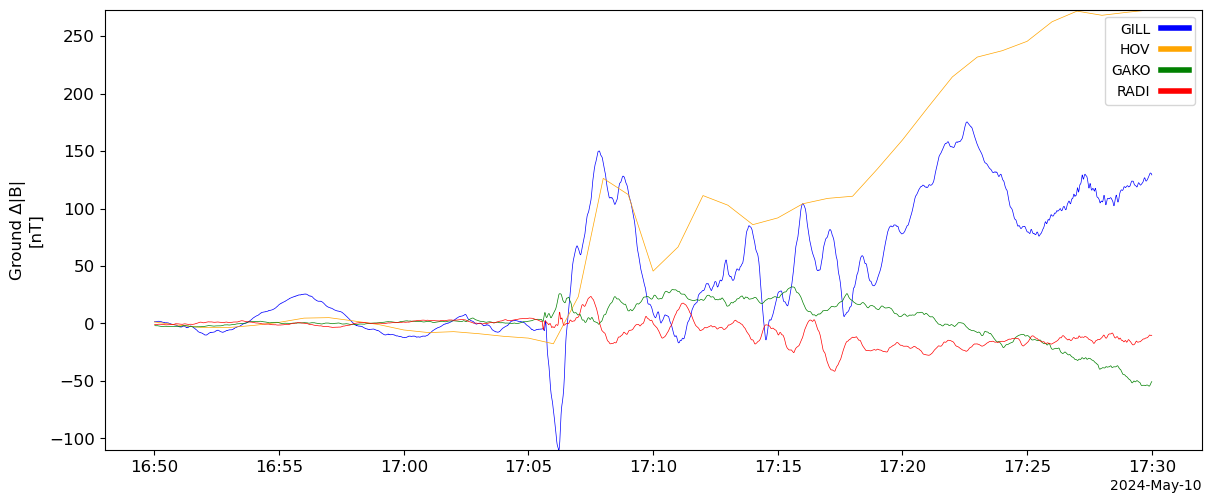

In [11]:
baseline_end = time_double("2024-05-10/17:00")
ground_delta = {}

for site in sites:
    data = get_data(site_vars[site])
    b_magnitude = np.linalg.norm(data.y, axis=1)
    baseline = np.nanmedian(b_magnitude[data.times < baseline_end])
    derived_name = f"delta_Bmag_{site.upper()}"
    store_data(derived_name, data={"x": data.times, "y": b_magnitude - baseline})
    options(derived_name, "ysubtitle", "[nT]")
    ground_delta[site] = derived_name

# A pseudo-variable overlays stations with different native cadences.
store_data("ground_delta_Bmag", data=[ground_delta[site] for site in sites])
options("ground_delta_Bmag", "ytitle", "Ground Δ|B|")
options("ground_delta_Bmag", "ysubtitle", "[nT]")
options("ground_delta_Bmag", "legend_names", [site.upper() for site in sites])
options("ground_delta_Bmag", "color", ["blue", "orange", "green", "red"])
tplot("ground_delta_Bmag", xsize=12, ysize=5)

Despite their very similar nominal magnetic latitudes, HOV (about 64.0°, IGRF $L \approx 5.20$) responds much more strongly than GAKO (about 63.8°, $L \approx 5.12$). Notice also that HOV has 60 s source cadence, so use this figure to compare the several-minute response amplitude—not high-frequency variability. The magnetic latitudes and quiet-time IGRF L values are reported by Fu et al.; they are not calculated from these traces.

## 5. Space and ground observations together

For a focused comparison we extract THEMIS-A $B_z$ and $V_x$ from the GSM vectors. The vertical guides mark the reported primary crossing (red), onset of the strong ground response (orange), and the two later boundary encounters (gray).

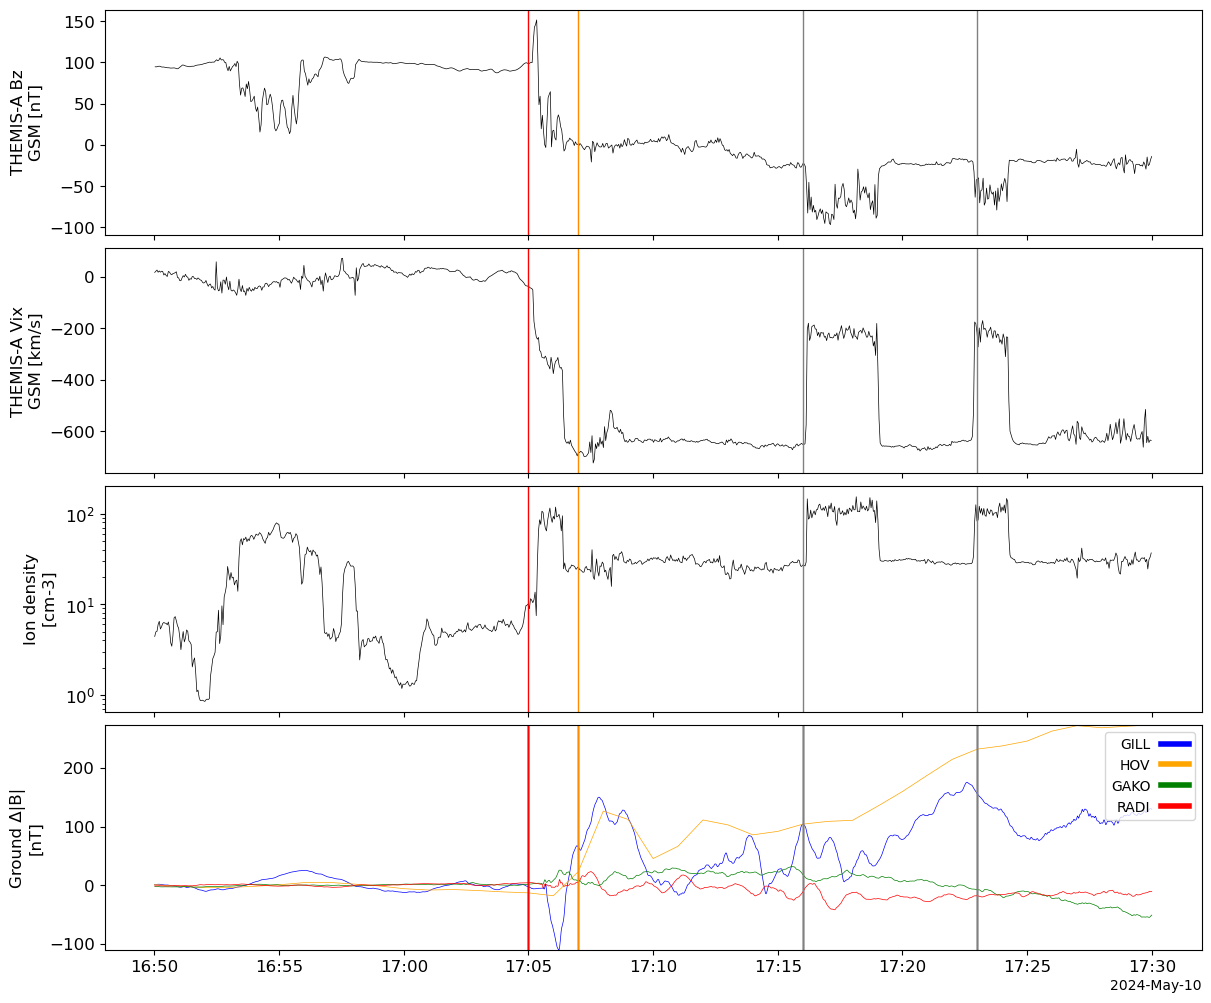

In [12]:
a_b_data = get_data(a_b_gsm)
a_v_data = get_data(a_velocity)
store_data("tha_Bz_GSM", data={"x": a_b_data.times, "y": a_b_data.y[:, 2]})
store_data("tha_Vix_GSM", data={"x": a_v_data.times, "y": a_v_data.y[:, 0]})
options("tha_Bz_GSM", "ytitle", "THEMIS-A Bz")
options("tha_Bz_GSM", "ysubtitle", "GSM [nT]")
options("tha_Vix_GSM", "ytitle", "THEMIS-A Vix")
options("tha_Vix_GSM", "ysubtitle", "GSM [km/s]")

for event_time, color in [
    ("2024-05-10/17:05", "red"),
    ("2024-05-10/17:07", "darkorange"),
    ("2024-05-10/17:16", "gray"),
    ("2024-05-10/17:23", "gray"),
]:
    timebar(time_double(event_time), color=color, thick=1)

tplot(
    ["tha_Bz_GSM", "tha_Vix_GSM", a_density, "ground_delta_Bmag"],
    xsize=12, ysize=10,
)

## 6. Questions for exploration

1. Ignoring the vertical guides at first, what time would you assign to the main THEMIS-A boundary crossing from $B_z$? How does your estimate change when you include $V_x$ and density?
2. When do HOV and GAKO begin to diverge? Is the difference mainly a short impulse or a sustained offset?
3. Add neighboring stations from the paper (`fykn`, `fsim`, `eagl`, `fsmi`, `pokr`, `kena`, and `sept`) to `sites`. How sharp is the change with the paper's listed magnetic latitude? Check the cadence and gaps for every added station.
4. What magnetic-field and velocity signatures support possible additional boundary encounters near 17:16 and 17:23 UT?
5. Estimate the delay from the THEMIS-B magnetic transition to (a) the THEMIS-A crossing and (b) the ground response. Why is this only a rough propagation estimate?

**Extension:** try plotting the local H, E, and Z components separately. Does using $|B|$ hide any useful directional information?

## 7. Scientific takeaway

Directly visible here are an abrupt THEMIS-A magnetic transition, subsequent fast plasma flow, an earlier upstream magnetic transition at THEMIS-B, and a strong spatial gradient in the simultaneous ground response. Together they show how measurements from different observational domains can describe one system-level event.

The quantitative **5.12–5.20 $R_E$** subsolar standoff-distance constraint is a result reported by Fu et al., based on the contrasting HOV and GAKO responses plus quiet-time IGRF mapping; it is not independently derived by this notebook. Their empirical model estimate was about 5.15 $R_E$. The notebook observations are consistent with extreme compression to roughly geosynchronous-orbit scales and motivate that published analysis.

## Instructor notes and current caveats

- THEMIS loaders download daily CDF files even though `time_clip=True` restricts the in-memory interval. On a fresh machine the largest files used here are tens of MB, so the first run can take a few minutes; reruns use the local cache.
- In PySPEDAS 2.2.0, tplot functions are imported from `pyspedas`; older examples that use a separate `pytplot` package need updating.
- `tha_peir_*` means reduced ESA ion moments and gives about 2.74 s cadence here. The `tha_peif_*` full-distribution moments are much sparser in this interval.
- Ground variables are named `thg_mag_<site>` and contain local HEZ vectors. HOV is available at 60 s cadence, versus about 0.5–1 s for the other three stations, so cadence must be considered in detailed comparisons.
- The four requested ground stations have coverage over the full tutorial interval. A final expanded station chain should still check each returned variable, cadence, and data gaps explicitly.
- THEMIS-B Level-2 MOM provides finite onboard ion density and GSM velocity at about 4.3 s cadence. Its $V_x$ contains brief sign reversals even among otherwise usable samples, so the tutorial emphasizes the sustained flow and pressure change rather than individual spikes. The proton-only dynamic pressure excludes alpha-particle and composition corrections.
- The reduced THEMIS-B ESA density has coverage, but its reduced velocity is fill data (consistent with an omnidirectional mode), while the full-distribution moments have only a few samples. MOM is therefore the appropriate upstream plasma product for this tutorial.
- The baseline-subtracted $|B|$ comparison is intentionally simple. A later version could make the station validation, baseline selection, cadence reporting, and optional component plots reusable.
- tplot defaults are serviceable, but final classroom polish may benefit from larger fonts and explicit annotations added to returned Matplotlib axes.